In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
experiment_dir = Path("/dcs/large/u1508153/misdro/anomalies")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col="uuid")

/tmp/dcs-tmp.u1508153/ipykernel_1025180/2246055442.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(bayes_df["var_cost"][i], bayes_df["mean_cost"][i], label, ha='left', va='bottom')


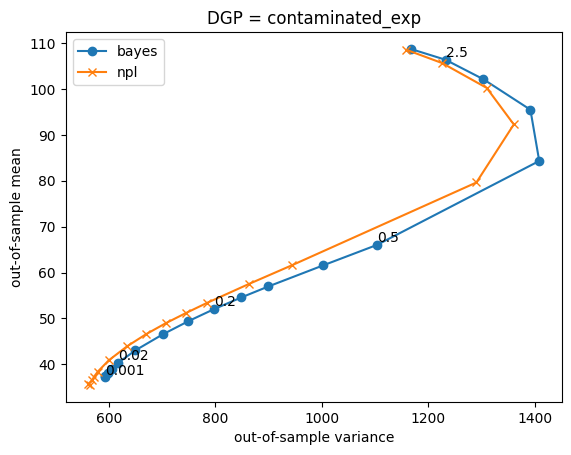

In [6]:
dgp = "contaminated_exp"
bayes_df = results_df.loc[(results_df["mean_cost"].notna()) & (results_df["posterior"] == "bayes") & (results_df["dgp"] == dgp)]
npl_df = results_df.loc[(results_df["mean_cost"].notna()) & (results_df["posterior"] == "npl") & (results_df["dgp"] == dgp)]

plt.plot(bayes_df["var_cost"], bayes_df["mean_cost"], marker='o', label="bayes")
plt.plot(npl_df["var_cost"], npl_df["mean_cost"], marker="x", label="npl")
plt.title(f"DGP = {dgp}")
plt.legend()
plt.xlabel("out-of-sample variance")
plt.ylabel("out-of-sample mean")
for i, label in enumerate(bayes_df["epsilon"]):
    if i % 4 == 0:
        plt.text(bayes_df["var_cost"][i], bayes_df["mean_cost"][i], label, ha='left', va='bottom')
    # if (i+2) % 4 == 0:
    #     plt.text(npl_df["var_cost"][i], npl_df["mean_cost"][i], label, ha='right', va='bottom')